In [54]:
import duckdb
import pandas as pd
import numpy as np
con = duckdb.connect(
r"C:\Users\howar\OneDrive\Documents\BU Mod2\699 pt2\Real Estate\gold\real_estate.duckdb"
)


ml_df = con.execute("""
SELECT *
FROM ml_tax_delinquency_2025
""").df()

ml_df = ml_df[
   (ml_df["building_area"] > 500) &
  (ml_df["total_market_value"] > 50000)
]

print(ml_df.shape)
ml_df.head()

(867574, 24)


,acct,tax_year,site_addr_1,situs_full,addr_key,addr_key_no_unit,owner_entity_flag,absentee_owner_flag,neighborhood_code,year_built,...,acreage,total_market_value,value_per_sqft,protested_flag,cnt_311_total_all,cnt_311_property_maintenance,cnt_311_vehicle_issues,cnt_311_building_standards,cnt_311_nuisance,target_tax_delinquent
0,0631170010002,2025,3007 WICHITA ST,3007 WICHITA ST HOUSTON 77004,3007 WICHITA ST,3007 WICHITA ST,0,1,8401.01,1911,...,0.1205,522171,189.742369,0,2,0.0,0.0,0.0,0.0,0
1,0631170010003,2025,3009 WICHITA ST,3009 WICHITA ST HOUSTON 77004,3009 WICHITA ST,3009 WICHITA ST,0,0,8401.01,1954,...,0.1205,277835,148.336893,0,2,1.0,0.0,0.0,0.0,0
2,0631170010004,2025,3015 WICHITA ST,3015 WICHITA ST HOUSTON 77004,3015 WICHITA ST,3015 WICHITA ST,0,0,8401.01,1949,...,0.1205,255561,150.065179,0,1,0.0,0.0,0.0,0.0,0
3,0631170010005,2025,3019 WICHITA ST,3019 WICHITA ST HOUSTON 77004,3019 WICHITA ST,3019 WICHITA ST,1,1,8401.01,1949,...,0.1205,243899,145.524463,0,3,0.0,0.0,2.0,0.0,0
4,0631170010010,2025,3115 WICHITA ST,3115 WICHITA ST HOUSTON 77004,3115 WICHITA ST,3115 WICHITA ST,0,1,8401.01,1940,...,0.1205,245940,102.347066,0,1,0.0,0.0,0.0,0.0,0


In [55]:
missing = ml_df.isna().sum().sort_values(ascending=False)

missing_pct = (missing / len(ml_df)) * 100

missing_df = pd.DataFrame({
    "missing_count": missing,
    "missing_pct": missing_pct
})

print(missing_df.head(20))

                              missing_count  missing_pct
years_owned                              25     0.002882
year_built                                1     0.000115
property_age                              1     0.000115
acct                                      0     0.000000
addr_key                                  0     0.000000
tax_year                                  0     0.000000
site_addr_1                               0     0.000000
situs_full                                0     0.000000
absentee_owner_flag                       0     0.000000
owner_entity_flag                         0     0.000000
addr_key_no_unit                          0     0.000000
neighborhood_code                         0     0.000000
building_area                             0     0.000000
lot_size                                  0     0.000000
acreage                                   0     0.000000
total_market_value                        0     0.000000
value_per_sqft                 

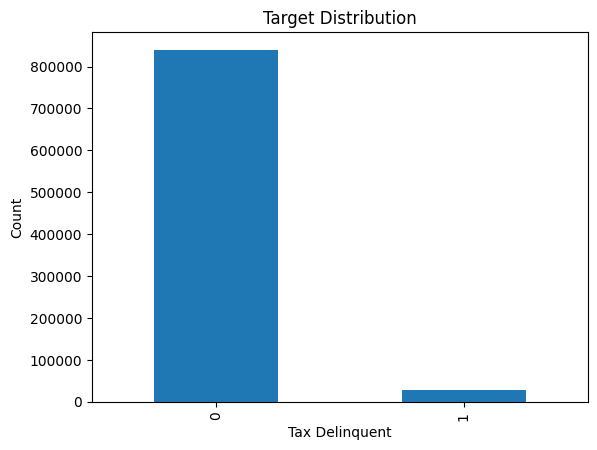

In [56]:
import matplotlib.pyplot as plt

ml_df["target_tax_delinquent"].value_counts().plot(kind="bar")

plt.title("Target Distribution")
plt.xlabel("Tax Delinquent")
plt.ylabel("Count")
plt.show()

In [57]:
ml_df["target_tax_delinquent"].value_counts(normalize=True)

target_tax_delinquent
0    0.968026
1    0.031974
Name: proportion, dtype: float64

In [58]:
numeric_cols = ml_df.select_dtypes(include=["int64","float64"]).columns

corr = ml_df[numeric_cols].corr()

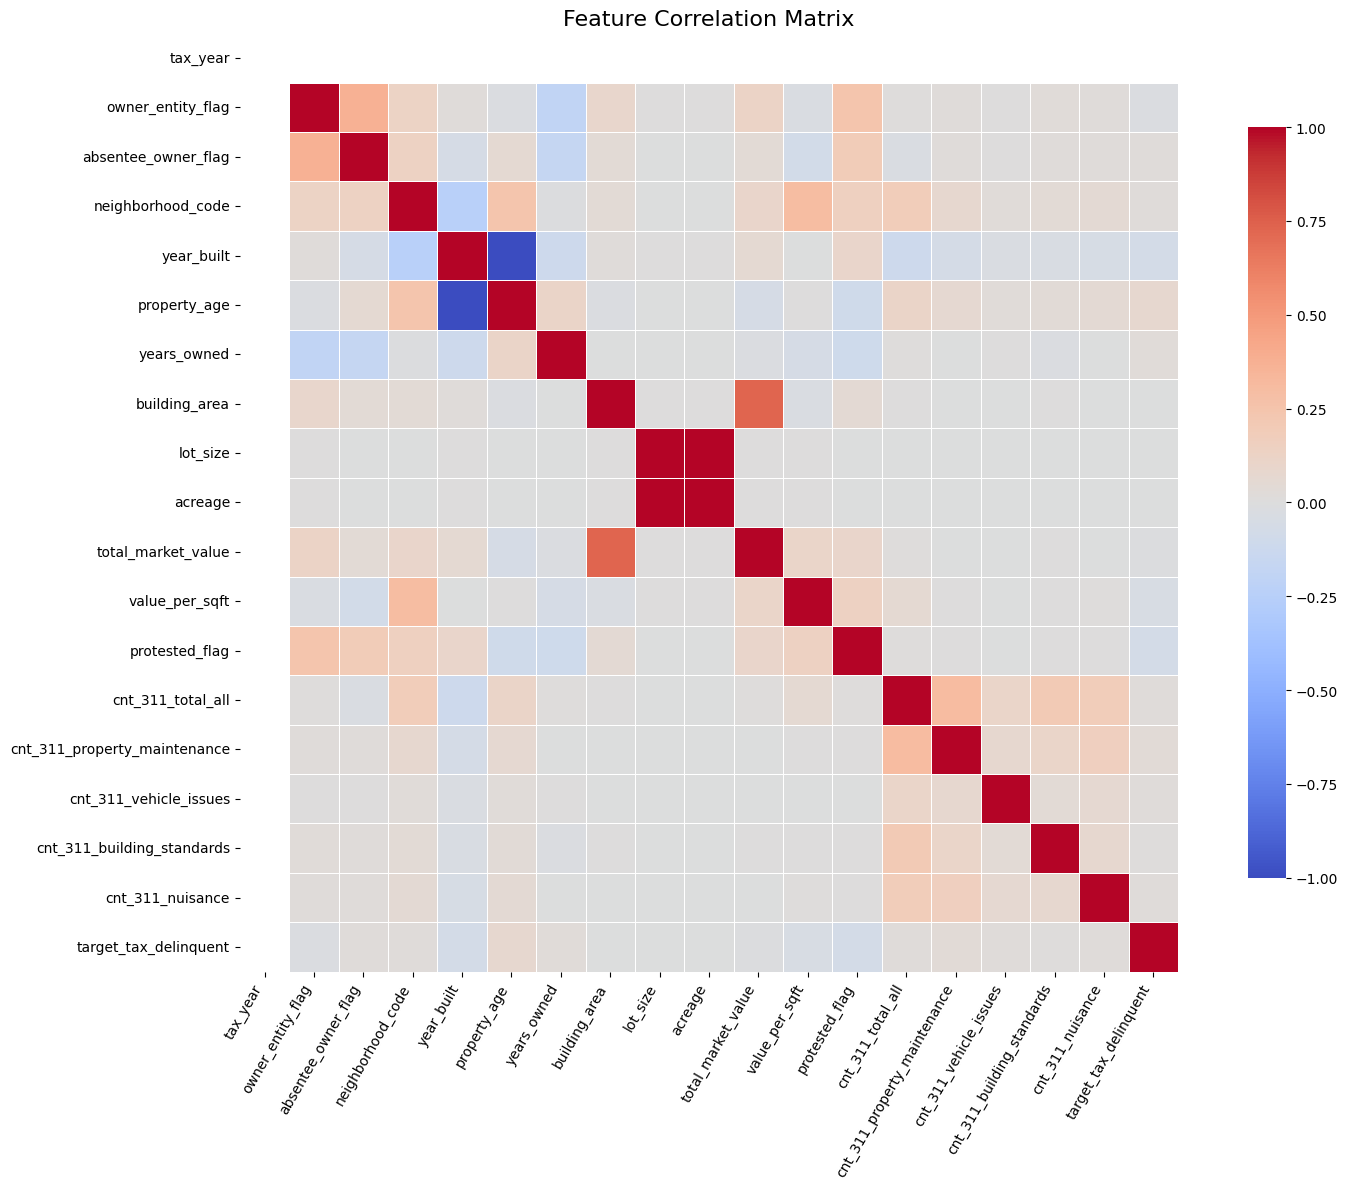

In [59]:
import matplotlib.pyplot as plt
import seaborn as sns

numeric_cols = ml_df.select_dtypes(include=["int64","float64"]).columns

corr = ml_df[numeric_cols].corr()

plt.figure(figsize=(16,12))

sns.heatmap(
    corr,
    cmap="coolwarm",
    center=0,
    square=True,
    linewidths=0.5,
    cbar_kws={"shrink":0.8}
)

plt.xticks(rotation=60, ha="right")
plt.yticks(rotation=0)

plt.title("Feature Correlation Matrix", fontsize=16)

plt.tight_layout()
plt.show()

In [60]:
target_corr = corr["target_tax_delinquent"].sort_values(ascending=False)

print(target_corr)

target_tax_delinquent           1.000000
property_age                    0.077503
cnt_311_property_maintenance    0.034813
years_owned                     0.025556
neighborhood_code               0.023276
cnt_311_nuisance                0.022389
absentee_owner_flag             0.019460
cnt_311_vehicle_issues          0.016509
cnt_311_total_all               0.016249
cnt_311_building_standards      0.011447
acreage                        -0.000233
lot_size                       -0.000233
building_area                  -0.003491
total_market_value             -0.012487
owner_entity_flag              -0.019980
value_per_sqft                 -0.044948
protested_flag                 -0.077302
year_built                     -0.077503
tax_year                             NaN
Name: target_tax_delinquent, dtype: float64


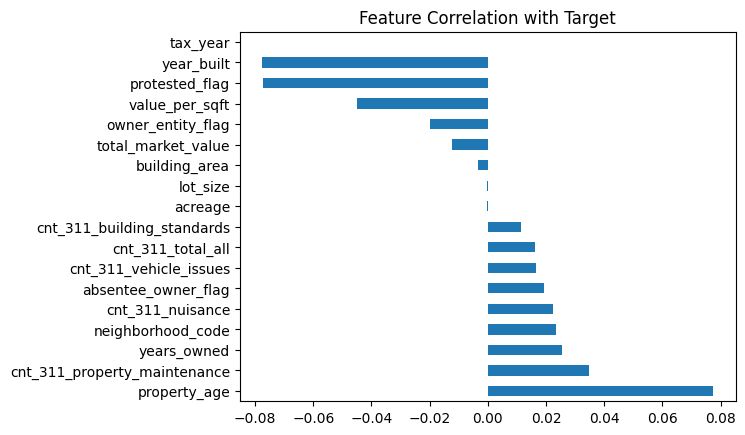

In [61]:
target_corr.drop("target_tax_delinquent").plot(kind="barh")

plt.title("Feature Correlation with Target")
plt.show()

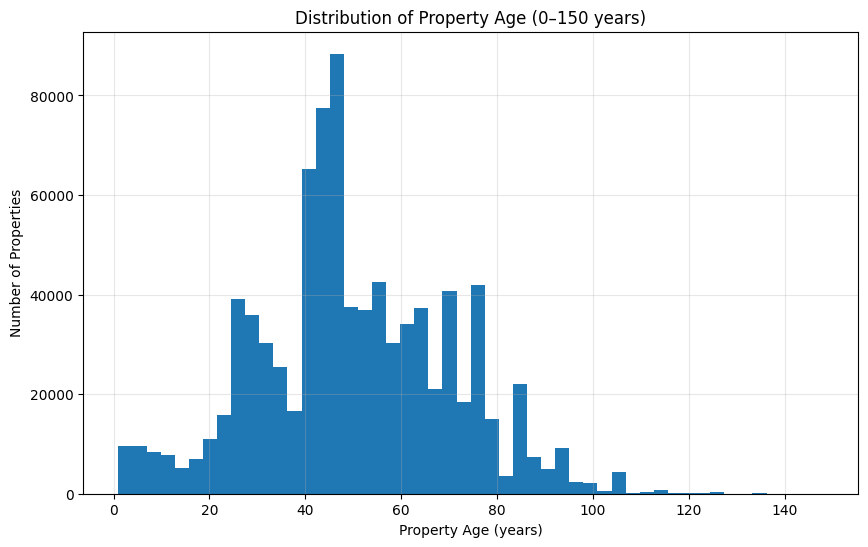

In [62]:
# keep realistic ages
age = ml_df["property_age"]
age = age[(age > 0) & (age < 150)]

plt.figure(figsize=(10,6))

plt.hist(age, bins=50)

plt.title("Distribution of Property Age (0–150 years)")
plt.xlabel("Property Age (years)")
plt.ylabel("Number of Properties")

plt.grid(alpha=0.3)

plt.show()

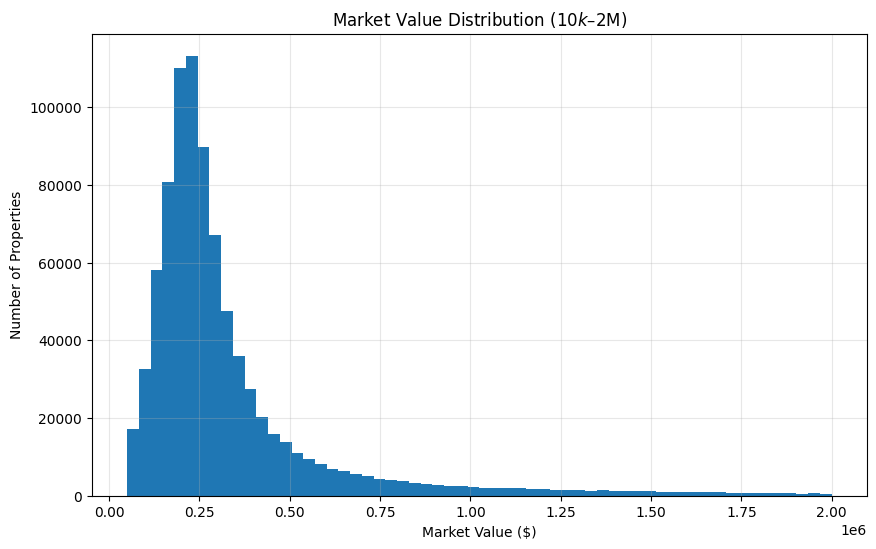

In [63]:
values = ml_df["total_market_value"]
values = values[(values > 10000) & (values < 2000000)]

plt.figure(figsize=(10,6))

plt.hist(values, bins=60)

plt.title("Market Value Distribution ($10k–$2M)")
plt.xlabel("Market Value ($)")
plt.ylabel("Number of Properties")

plt.grid(alpha=0.3)

plt.show()

C:\Users\howar\AppData\Local\Temp\ipykernel_4628\3589833467.py:7: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  bucket_rates = ml_df.groupby("value_bucket")["target_tax_delinquent"].mean()


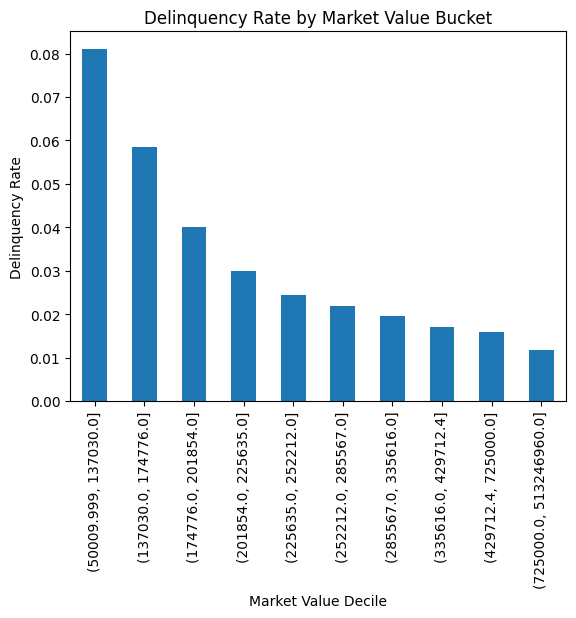

In [64]:
ml_df["value_bucket"] = pd.qcut(
    ml_df["total_market_value"],
    10,
    duplicates="drop"
)

bucket_rates = ml_df.groupby("value_bucket")["target_tax_delinquent"].mean()

bucket_rates.plot(kind="bar")

plt.title("Delinquency Rate by Market Value Bucket")
plt.ylabel("Delinquency Rate")
plt.xlabel("Market Value Decile")

plt.show()

C:\Users\howar\AppData\Local\Temp\ipykernel_4628\1543310978.py:15: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  ml_df.groupby("price_bucket")


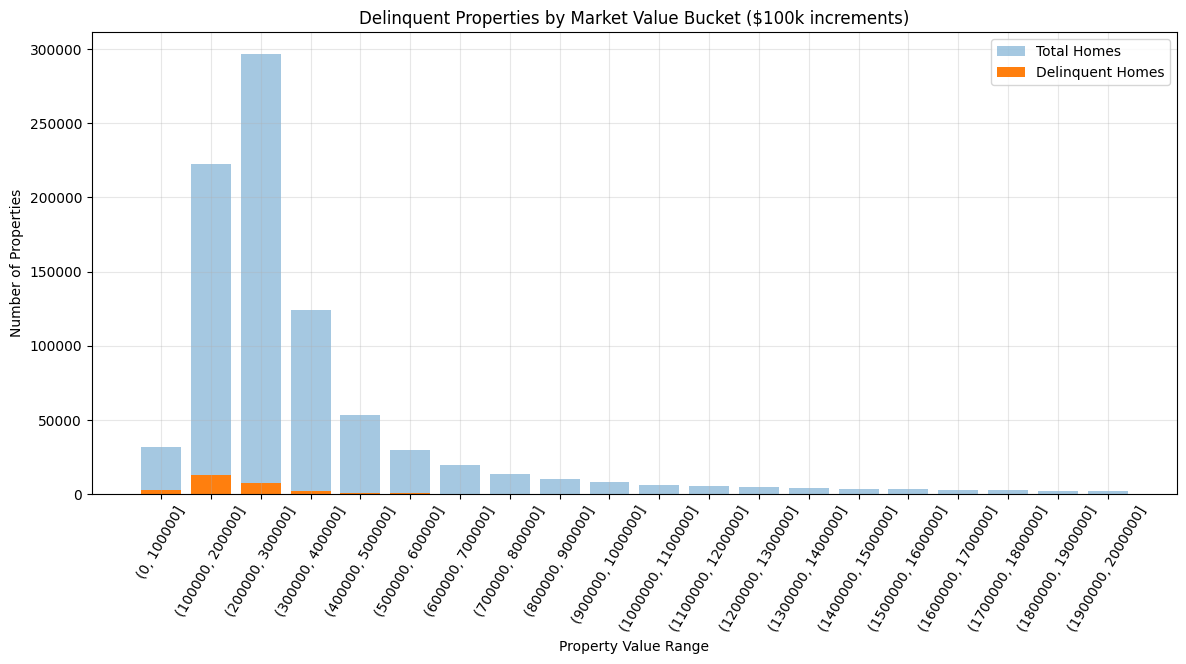

In [65]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

# create fixed bins every 100k up to 2M
bins = np.arange(0, 2000000 + 100000, 100000)

ml_df["price_bucket"] = pd.cut(
    ml_df["total_market_value"],
    bins=bins
)

# summarize
bucket_summary = (
    ml_df.groupby("price_bucket")
    .agg(
        total_properties=("acct","count"),
        delinquent=("target_tax_delinquent","sum")
    )
    .reset_index()
)

# plot
plt.figure(figsize=(14,6))

plt.bar(
    bucket_summary["price_bucket"].astype(str),
    bucket_summary["total_properties"],
    alpha=0.4,
    label="Total Homes"
)

plt.bar(
    bucket_summary["price_bucket"].astype(str),
    bucket_summary["delinquent"],
    label="Delinquent Homes"
)

plt.xticks(rotation=60)

plt.xlabel("Property Value Range")
plt.ylabel("Number of Properties")

plt.title("Delinquent Properties by Market Value Bucket ($100k increments)")

plt.legend()
plt.grid(alpha=0.3)

plt.show()

In [66]:
neighborhood_stats = (
    ml_df.groupby("neighborhood_code")
    .agg(
        n_properties=("acct", "count"),
        n_delinquent=("target_tax_delinquent", "sum"),
        delinquency_rate=("target_tax_delinquent", "mean")
    )
    .sort_values(["delinquency_rate", "n_properties"], ascending=[False, False])
)

print(neighborhood_stats.head(30))

                   n_properties  n_delinquent  delinquency_rate
neighborhood_code                                              
5637.01                      16            16          1.000000
946.05                        1             1          1.000000
9809.02                       1             1          1.000000
9824.08                       1             1          1.000000
9990.03                       1             1          1.000000
2699.07                      18            15          0.833333
2178.01                       5             4          0.800000
5672.05                       5             4          0.800000
9358.07                       2             1          0.500000
9700.05                       2             1          0.500000
9996.02                       2             1          0.500000
2499.08                      11             5          0.454545
2426.05                       7             3          0.428571
2500.05                      11         

<Axes: >

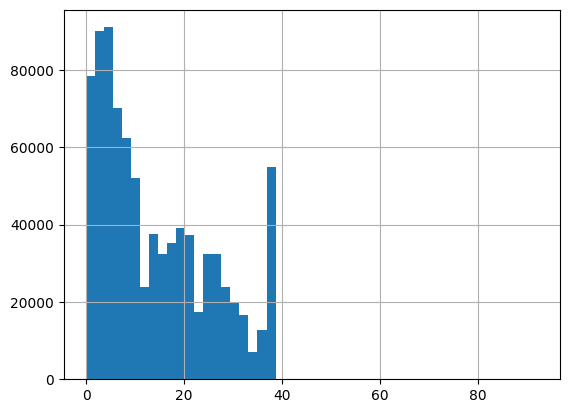

In [67]:
ml_df["years_owned"].hist(bins=50)

In [68]:
ml_df.groupby("target_tax_delinquent")["years_owned"].median()

target_tax_delinquent
0    11.0
1    13.0
Name: years_owned, dtype: Float64

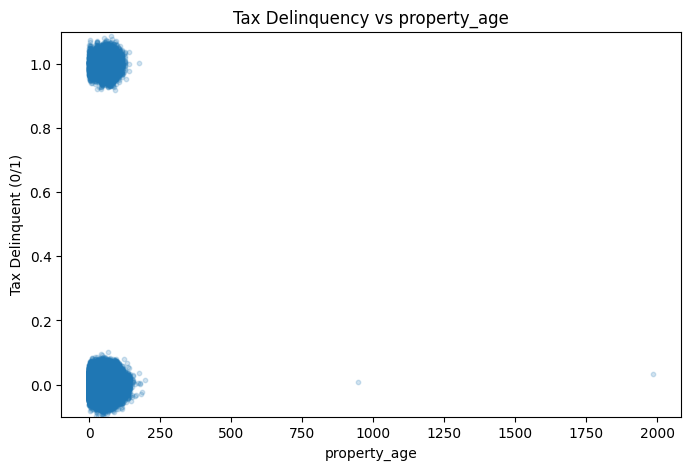

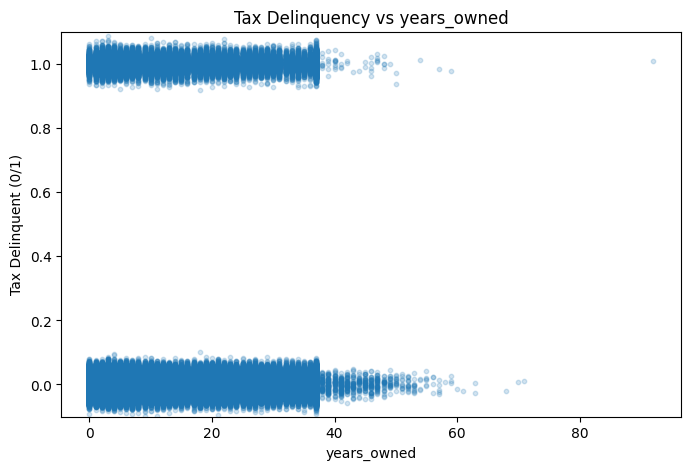

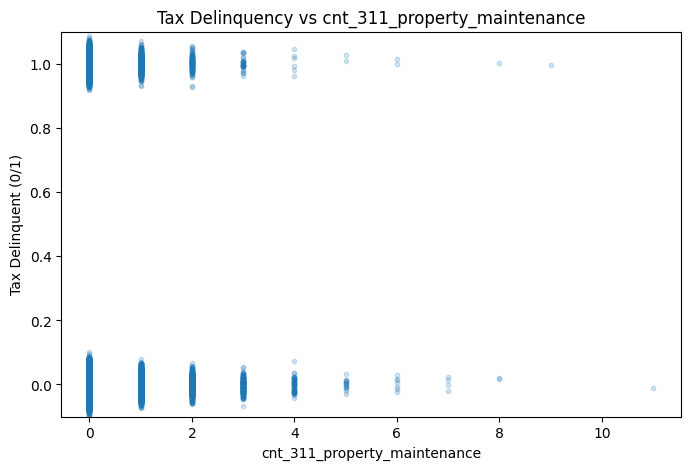

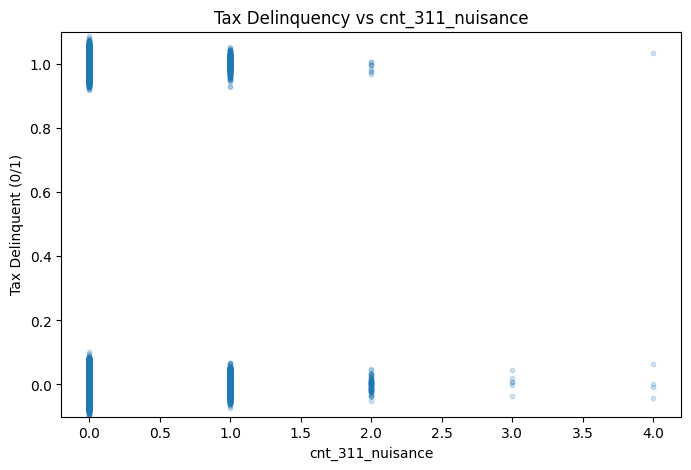

In [69]:
import matplotlib.pyplot as plt
import numpy as np

# small jitter so points don't overlap
y_jitter = ml_df["target_tax_delinquent"] + np.random.normal(0, 0.02, len(ml_df))

features = [
    "property_age",
    "years_owned",
    "cnt_311_property_maintenance",
    "cnt_311_nuisance"
]

for feature in features:

    plt.figure(figsize=(8,5))

    plt.scatter(
        ml_df[feature],
        y_jitter,
        alpha=0.2,
        s=10
    )

    plt.xlabel(feature)
    plt.ylabel("Tax Delinquent (0/1)")
    plt.title(f"Tax Delinquency vs {feature}")

    plt.ylim(-0.1,1.1)

    plt.show()

C:\Users\howar\AppData\Local\Temp\ipykernel_4628\3918122681.py:5: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  age_rate = ml_df.groupby("age_bin")["target_tax_delinquent"].mean()


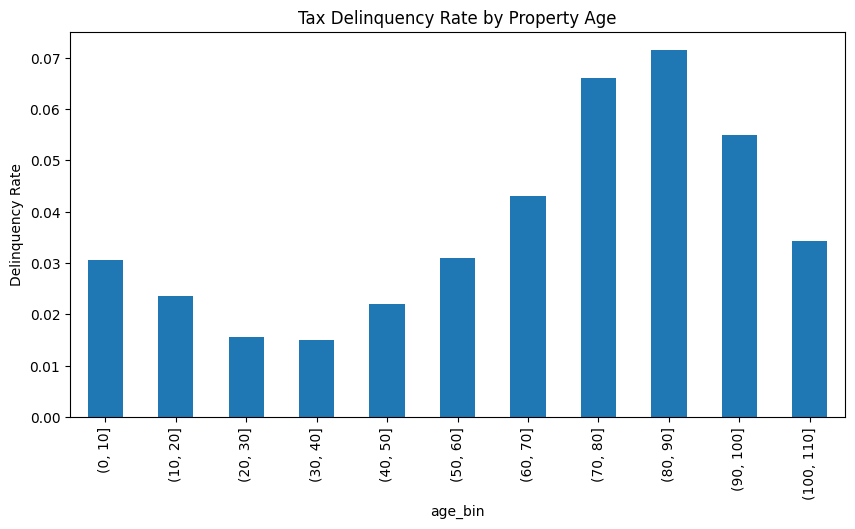

In [70]:
bins = np.arange(0,120,10)

ml_df["age_bin"] = pd.cut(ml_df["property_age"], bins)

age_rate = ml_df.groupby("age_bin")["target_tax_delinquent"].mean()

age_rate.plot(kind="bar", figsize=(10,5))

plt.ylabel("Delinquency Rate")
plt.title("Tax Delinquency Rate by Property Age")
plt.show()

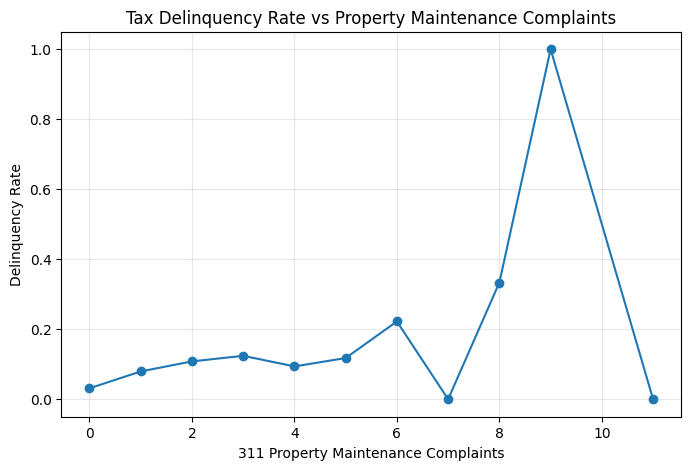

In [71]:
rate = (
    ml_df.groupby("cnt_311_property_maintenance")["target_tax_delinquent"]
    .mean()
)

count = (
    ml_df.groupby("cnt_311_property_maintenance")["acct"]
    .count()
)
subset = ml_df[ml_df["cnt_311_property_maintenance"] <= 5]
plt.figure(figsize=(8,5))

plt.plot(rate.index, rate.values, marker="o")

plt.xlabel("311 Property Maintenance Complaints")
plt.ylabel("Delinquency Rate")
plt.title("Tax Delinquency Rate vs Property Maintenance Complaints")

plt.grid(alpha=0.3)
plt.show()

In [72]:
print(pd.concat([rate, count], axis=1).rename(
    columns={0:"delinquency_rate", "acct":"n_properties"}
))

                              target_tax_delinquent  n_properties
cnt_311_property_maintenance                                     
0.0                                        0.031241        855359
1.0                                        0.079319         10691
2.0                                        0.108085          1175
3.0                                        0.124000           250
4.0                                        0.093750            64
5.0                                        0.117647            17
6.0                                        0.222222             9
7.0                                        0.000000             4
8.0                                        0.333333             3
9.0                                        1.000000             1
11.0                                       0.000000             1


C:\Users\howar\AppData\Local\Temp\ipykernel_4628\2591905273.py:6: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  ml_df.groupby("ownership_bin")["target_tax_delinquent"]


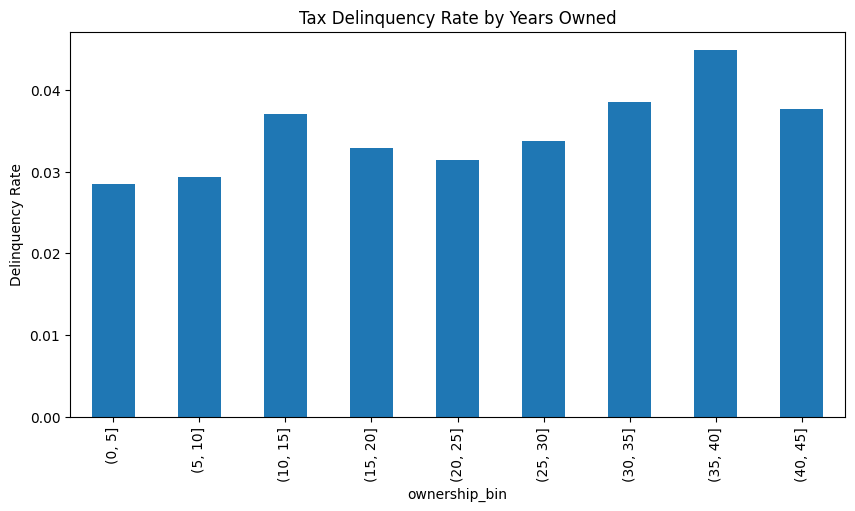

In [73]:
bins = np.arange(0,50,5)

ml_df["ownership_bin"] = pd.cut(ml_df["years_owned"], bins)

ownership_rate = (
    ml_df.groupby("ownership_bin")["target_tax_delinquent"]
    .mean()
)

ownership_rate.plot(kind="bar", figsize=(10,5))

plt.ylabel("Delinquency Rate")
plt.title("Tax Delinquency Rate by Years Owned")
plt.show()

C:\Users\howar\AppData\Local\Temp\ipykernel_4628\2271263403.py:15: FutureWarning: The default value of observed=False is deprecated and will change to observed=True in a future version of pandas. Specify observed=False to silence this warning and retain the current behavior
  heat = temp.pivot_table(


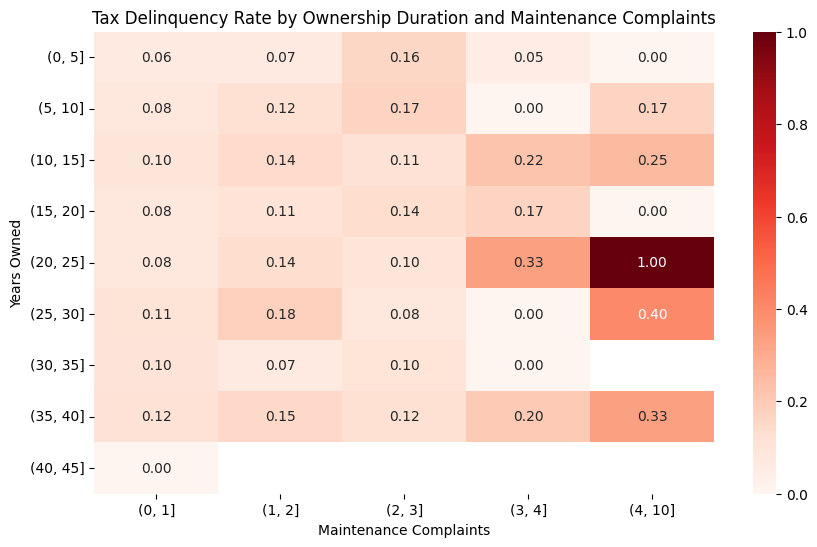

In [74]:
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

# temporary bins (no new ML feature created)
ownership_bins = np.arange(0,50,5)
complaint_bins = [0,1,2,3,4,10]

temp = ml_df.copy()

temp["ownership_bin"] = pd.cut(temp["years_owned"], ownership_bins)
temp["maintenance_bin"] = pd.cut(temp["cnt_311_property_maintenance"], complaint_bins)

heat = temp.pivot_table(
    values="target_tax_delinquent",
    index="ownership_bin",
    columns="maintenance_bin",
    aggfunc="mean"
)

plt.figure(figsize=(10,6))
sns.heatmap(
    heat,
    annot=True,
    fmt=".2f",
    cmap="Reds"
)

plt.title("Tax Delinquency Rate by Ownership Duration and Maintenance Complaints")
plt.xlabel("Maintenance Complaints")
plt.ylabel("Years Owned")

plt.show()

X shape: (867574, 17)
Feature columns:
['owner_entity_flag', 'absentee_owner_flag', 'neighborhood_code', 'year_built', 'property_age', 'years_owned', 'building_area', 'lot_size', 'acreage', 'total_market_value', 'value_per_sqft', 'protested_flag', 'cnt_311_total_all', 'cnt_311_property_maintenance', 'cnt_311_vehicle_issues', 'cnt_311_building_standards', 'cnt_311_nuisance']
              precision    recall  f1-score   support

           0       0.98      0.84      0.90    167967
           1       0.09      0.51      0.16      5548

    accuracy                           0.83    173515
   macro avg       0.54      0.67      0.53    173515
weighted avg       0.95      0.83      0.88    173515

ROC AUC: 0.761936414094352

Top 20 features:
total_market_value              0.183389
value_per_sqft                  0.120590
building_area                   0.105555
neighborhood_code               0.104771
protested_flag                  0.087858
property_age                    0.085245
year_

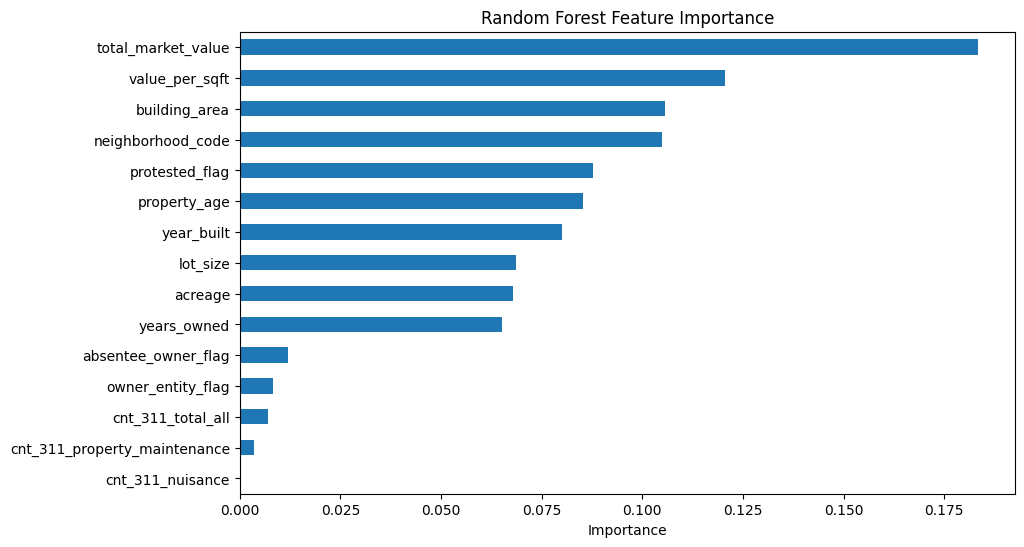

In [75]:
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import classification_report, roc_auc_score
import pandas as pd
import matplotlib.pyplot as plt

# columns we do NOT want in the model
drop_cols = [
    "acct",
    "site_addr_1",
    "situs_full",
    "addr_key",
    "addr_key_no_unit",
    "tax_year",
    "target_tax_delinquent",
    "age_bin",
    "ownership_bin",
    "price_bucket",
    "value_bucket",
    "price_bucket_label",
]

# keep only columns that actually exist
drop_cols = [c for c in drop_cols if c in ml_df.columns]

X = ml_df.drop(columns=drop_cols, errors="ignore").copy()
y = ml_df["target_tax_delinquent"].copy()

# keep numeric columns only
X = X.select_dtypes(include=["number", "bool"]).copy()

# convert bools to int
for c in X.select_dtypes(include=["bool"]).columns:
    X[c] = X[c].astype(int)

# fill missing numeric values
X = X.apply(pd.to_numeric, errors="coerce")
X = X.fillna(0)

print("X shape:", X.shape)
print("Feature columns:")
print(X.columns.tolist())

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

rf = RandomForestClassifier(
    n_estimators=300,
    max_depth=45,
    min_samples_leaf=55,
    class_weight="balanced",
    random_state=42,
    n_jobs=-1
)


rf.fit(X_train, y_train)

preds = rf.predict(X_test)
probs = rf.predict_proba(X_test)[:, 1]

print(classification_report(y_test, preds))
print("ROC AUC:", roc_auc_score(y_test, probs))

importance = pd.Series(rf.feature_importances_, index=X.columns).sort_values(ascending=False)

print("\nTop 20 features:")
print(importance.head(20))

plt.figure(figsize=(10, 6))
importance.head(15).sort_values().plot(kind="barh")
plt.title("Random Forest Feature Importance")
plt.xlabel("Importance")
plt.show()

In [76]:
import pandas as pd

importance = pd.Series(
    rf.feature_importances_,
    index=X.columns
).sort_values(ascending=False)

print(importance.head(20))

total_market_value              0.183389
value_per_sqft                  0.120590
building_area                   0.105555
neighborhood_code               0.104771
protested_flag                  0.087858
property_age                    0.085245
year_built                      0.080124
lot_size                        0.068545
acreage                         0.067799
years_owned                     0.065021
absentee_owner_flag             0.011950
owner_entity_flag               0.008313
cnt_311_total_all               0.006909
cnt_311_property_maintenance    0.003451
cnt_311_nuisance                0.000270
cnt_311_building_standards      0.000184
cnt_311_vehicle_issues          0.000027
dtype: float64


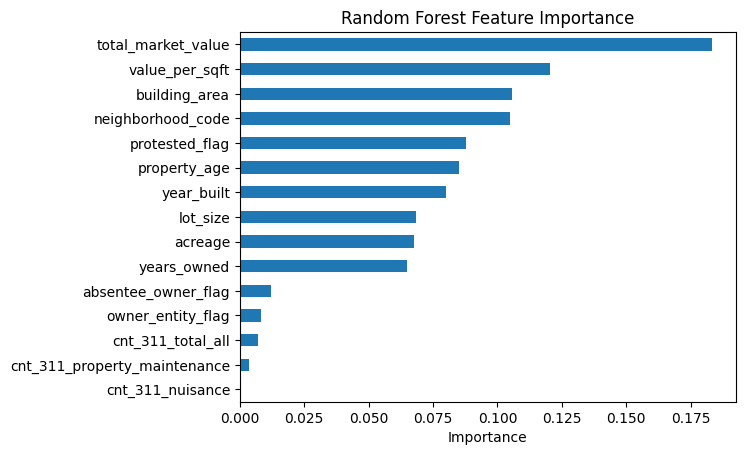

In [77]:
import matplotlib.pyplot as plt

importance.head(15).plot(kind="barh")

plt.title("Random Forest Feature Importance")
plt.xlabel("Importance")
plt.gca().invert_yaxis()

plt.show()

In [78]:
import pandas as pd
import numpy as np

# build dataframe of predictions
lift_df = pd.DataFrame({
    "prob": probs,
    "actual": y_test
})

# create deciles (10 buckets)
lift_df["decile"] = pd.qcut(lift_df["prob"], 10, labels=False, duplicates="drop")

# flip order so 10 = highest risk
lift_df["decile"] = 9 - lift_df["decile"]

# calculate stats per decile
decile_table = lift_df.groupby("decile").agg(
    n_properties=("actual", "count"),
    n_delinquent=("actual", "sum"),
    delinquency_rate=("actual", "mean")
).reset_index()

# calculate lift
baseline_rate = lift_df["actual"].mean()
decile_table["lift"] = decile_table["delinquency_rate"] / baseline_rate

print(decile_table)

   decile  n_properties  n_delinquent  delinquency_rate      lift
0       0         17352          2009          0.115779  3.621020
1       1         17351          1044          0.060169  1.881813
2       2         17352           737          0.042473  1.328368
3       3         17351           536          0.030892  0.966142
4       4         17351           341          0.019653  0.614654
5       5         17352           288          0.016598  0.519091
6       6         17351           204          0.011757  0.367711
7       7         17352           189          0.010892  0.340653
8       8         17351           129          0.007435  0.232523
9       9         17352            71          0.004092  0.127970


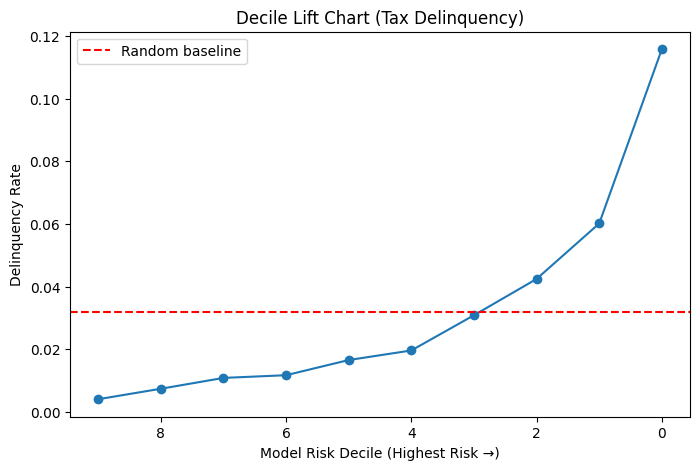

In [79]:
import matplotlib.pyplot as plt

plt.figure(figsize=(8,5))

plt.plot(decile_table["decile"], decile_table["delinquency_rate"], marker="o")

plt.axhline(
    y=baseline_rate,
    color="red",
    linestyle="--",
    label="Random baseline"
)

plt.gca().invert_xaxis()

plt.title("Decile Lift Chart (Tax Delinquency)")
plt.xlabel("Model Risk Decile (Highest Risk →)")
plt.ylabel("Delinquency Rate")

plt.legend()
plt.show()

In [80]:
# predict probability of delinquency
ml_df["rf_distress_score"] = rf.predict_proba(X)[:,1]

ml_df[["rf_distress_score","target_tax_delinquent"]].head()

,rf_distress_score,target_tax_delinquent
0,0.477179,0
1,0.610779,0
2,0.594987,0
3,0.582411,0
4,0.602146,0


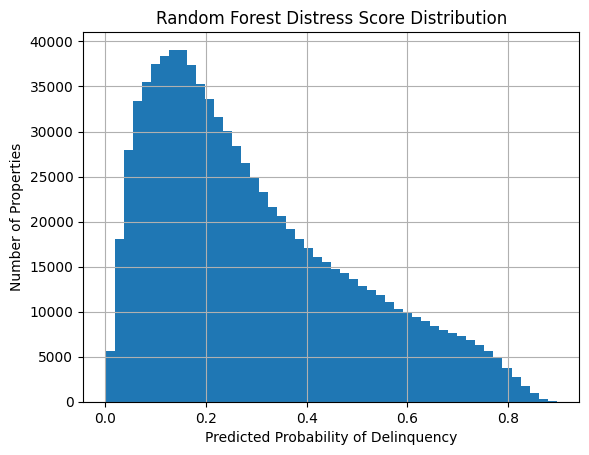

In [81]:
ml_df["rf_distress_score"].hist(bins=50)

plt.title("Random Forest Distress Score Distribution")
plt.xlabel("Predicted Probability of Delinquency")
plt.ylabel("Number of Properties")
plt.show()

In [82]:
ml_df["distress_tier"] = pd.qcut(
    ml_df["rf_distress_score"],
    q=10,
    labels=False
)

In [83]:
ml_df.groupby("distress_tier")["target_tax_delinquent"].mean()

distress_tier
0    0.000818
1    0.001475
2    0.002178
3    0.002317
4    0.003343
5    0.005717
6    0.017105
7    0.042959
8    0.074645
9    0.169183
Name: target_tax_delinquent, dtype: float64

In [84]:
from IPython.display import display, HTML

df_view = ml_df.sort_values(
    "rf_distress_score",
    ascending=False
)[[
    "acct",
    "site_addr_1",
    "rf_distress_score",
    "total_market_value",
    "years_owned",
    "cnt_311_property_maintenance"
]].head(3000)

display(HTML(
    '<div style="height:400px; overflow:auto;">'
    + df_view.to_html()
    + '</div>'
))

,acct,site_addr_1,rf_distress_score,total_market_value,years_owned,cnt_311_property_maintenance
1046439,0780290120007,2626 BERTRAND ST,0.896447,71154,37,0.0
1034449,0720760010014,4402 WEAVER RD,0.895503,76744,14,0.0
690656,0701070150140,3515 HARDIE ST,0.892378,85371,7,0.0
1046435,0780290110008,2430 BERTRAND ST,0.890694,69684,10,0.0
1010184,0760190100219,5418 WILEY RD,0.890262,77005,37,0.0
1034166,0700110120025,210 DE HAVEN ST,0.889828,89176,4,0.0
765624,0302350220030,4922 CREEKMONT DR,0.888877,74135,37,0.0
1046442,0780290130015,2910 BERTRAND ST,0.888072,77217,37,0.0
1046436,0780290110012,2510 BERTRAND ST,0.887678,72152,13,0.0
1041455,0142250000011,3206 FLORIDA ST,0.887276,85306,10,0.0
